In [25]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, balanced_accuracy_score,
    cohen_kappa_score, matthews_corrcoef
)

import seaborn as sns

In [30]:
# ====== imports you need at top of your file ======
import numpy as np
import pandas as pd
from typing import List, Dict, Any, Tuple
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, accuracy_score,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef
)

# ---------- helpers ----------
def _to_bin(arr) -> np.ndarray:
    """Coerce an array/Series to clean 0/1 ints."""
    s = pd.Series(arr).fillna(0)
    s = s.replace({'True': 1, 'False': 0, 'true': 1, 'false': 0})
    s = pd.to_numeric(s, errors='coerce').fillna(0.0)
    return (s > 0.5).astype(int).to_numpy()

def _align_by_xcorr(gt: np.ndarray, pred: np.ndarray, max_lag_frames: int = 30) -> Tuple[np.ndarray, int]:
    """
    Estimate a fixed lag via cross-correlation and shift pred to maximize agreement.
    Robust to constant/empty inputs.
    """
    gt = _to_bin(gt)
    pred = _to_bin(pred)
    n = len(gt)
    if n == 0 or len(pred) != n:
        return pred, 0

    a = gt.astype(float)
    b = pred.astype(float)
    # center, guard against constant arrays
    a -= a.mean() if n > 0 else 0.0
    b -= b.mean() if n > 0 else 0.0
    if (np.allclose(a, 0) and np.allclose(b, 0)) or n == 1:
        return pred, 0

    ac = np.correlate(a, b, mode='full')
    lags = np.arange(-n + 1, n)
    m = (lags >= -max_lag_frames) & (lags <= max_lag_frames)
    if not np.any(m):
        return pred, 0
    best_lag = int(lags[m][np.argmax(ac[m])])

    if best_lag > 0:
        pred_aligned = np.r_[np.zeros(best_lag, dtype=int), pred[:-best_lag]]
    elif best_lag < 0:
        pred_aligned = np.r_[pred[-best_lag:], np.zeros(-best_lag, dtype=int)]
    else:
        pred_aligned = pred
    return pred_aligned.astype(int), best_lag

def _segments_from_binary(x) -> List[Tuple[int, int]]:
    """Return [(start,end)] inclusive for contiguous 1-runs."""
    x = _to_bin(x)
    if len(x) == 0:
        return []
    starts = np.where((x[1:] == 1) & (x[:-1] == 0))[0] + 1
    ends   = np.where((x[1:] == 0) & (x[:-1] == 1))[0]
    if x[0] == 1:  starts = np.r_[0, starts]
    if x[-1] == 1: ends   = np.r_[ends, len(x) - 1]
    return [(int(s), int(e)) for s, e in zip(starts, ends)]

def _safe_stats(values: List[float]) -> Dict[str, float]:
    if len(values) == 0:
        return dict(mean=np.nan, median=np.nan, std=np.nan)
    a = np.asarray(values, float)
    return dict(mean=float(a.mean()), median=float(np.median(a)), std=float(a.std(ddof=0)))

def _match_segments(gt_seg, pr_seg, onset_tol_frames=2, min_iou=0.5):
    """
    Greedy 1-1 matching by nearest onset. A match is OK if |onset_err| <= tol and IoU >= min_iou.
    """
    used = set()
    matches = []
    ok_pred = set()

    for gi, (gs, ge) in enumerate(gt_seg):
        if len(pr_seg) == 0:
            matches.append(None)
            continue
        cand = [(pi, ps, pe) for pi, (ps, pe) in enumerate(pr_seg) if pi not in used]
        if not cand:
            matches.append(None)
            continue
        pi, ps, pe = min(cand, key=lambda t: abs(t[1] - gs))

        onset_err = ps - gs
        overlap = max(0, min(ge, pe) - max(gs, ps) + 1)
        union = (ge - gs + 1) + (pe - ps + 1) - overlap
        iou = (overlap / union) if union > 0 else 0.0
        ok = (abs(onset_err) <= onset_tol_frames) and (iou >= min_iou)

        matches.append(dict(pred_idx=pi, onset_err=onset_err, offset_err=(pe - ge), iou=iou, ok=ok))
        used.add(pi)
        if ok:
            ok_pred.add(pi)

    return matches, ok_pred

# ---------- main evaluator ----------
def compute_pedal_metrics(
    gt_pedal, pds_pedal,
    fps=30.0,
    estimate_lag=True,
    max_lag_seconds=0.5,     # search window for fixed lag
    onset_tol_ms=50,         # tolerance for onset (segment-level)
    min_iou=0.5              # minimum temporal IoU for a segment to count
) -> Dict[str, Any]:
    gt = _to_bin(gt_pedal)
    pr = _to_bin(pds_pedal)
    if gt.shape != pr.shape:
        raise ValueError("gt and pred must be same-length arrays")

    # Optional fixed-lag alignment (applied to predictions)
    lag_frames = 0
    if estimate_lag and fps and fps > 0:
        max_lag_frames = int(round(max_lag_seconds * fps))
        pr, lag_frames = _align_by_xcorr(gt, pr, max_lag_frames=max_lag_frames)

    # ---- frame-level metrics ----
    tn, fp, fn, tp = confusion_matrix(gt, pr, labels=[0, 1]).ravel()
    N = len(gt)
    accuracy = (tp + tn) / N if N > 0 else np.nan
    precision = precision_score(gt, pr, zero_division=0)
    recall = recall_score(gt, pr, zero_division=0)
    f1 = f1_score(gt, pr, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    bal_acc = balanced_accuracy_score(gt, pr)
    kappa = cohen_kappa_score(gt, pr)
    mcc = matthews_corrcoef(gt, pr) if (tp + tn + fp + fn) > 0 else np.nan

    # Temporal IoU over the active time (global)
    inter = np.logical_and(gt == 1, pr == 1).sum()
    union = np.logical_or(gt == 1, pr == 1).sum()
    temporal_iou = (inter / union) if union > 0 else (1.0 if inter == 0 else 0.0)

    # ---- segment / event metrics ----
    gt_seg = _segments_from_binary(gt)
    pr_seg = _segments_from_binary(pr)
    onset_tol_frames = int(round((onset_tol_ms / 1000.0) * fps)) if fps and fps > 0 else 0
    matches, ok_pred = _match_segments(gt_seg, pr_seg, onset_tol_frames=onset_tol_frames, min_iou=min_iou)

    num_gt = len(gt_seg)
    ok_count = sum(1 for m in matches if (m is not None and m["ok"]))
    seg_recall = ok_count / num_gt if num_gt > 0 else (1.0 if len(pr_seg) == 0 else 0.0)

    num_pr = len(pr_seg)
    seg_precision = len(ok_pred) / num_pr if num_pr > 0 else (1.0 if num_gt == 0 else 0.0)
    seg_f1 = (2 * seg_precision * seg_recall / (seg_precision + seg_recall)) if (seg_precision + seg_recall) > 0 else 0.0

    # onset/offset errors
    onset_errs = [m["onset_err"] for m in matches if m is not None]
    offset_errs = [m["offset_err"] for m in matches if m is not None]
    onset_stats_f = _safe_stats(onset_errs)
    offset_stats_f = _safe_stats(offset_errs)

    # convert to ms
    frame_to_ms = 1000.0 / fps if fps and fps > 0 else np.nan
    onset_stats_ms = {k: (v * frame_to_ms if pd.notna(v) else np.nan) for k, v in onset_stats_f.items()}
    offset_stats_ms = {k: (v * frame_to_ms if pd.notna(v) else np.nan) for k, v in offset_stats_f.items()}

    # spurious activation rate (per minute)
    spurious = num_pr - len(ok_pred)
    duration_min = (N / fps) / 60.0 if fps and fps > 0 else np.nan
    spurious_per_min = (spurious / duration_min) if duration_min and duration_min > 0 else np.nan

    return dict(
        frames=int(N), tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
        accuracy=float(accuracy), precision=float(precision), recall=float(recall), f1=float(f1),
        specificity=float(specificity), balanced_accuracy=float(bal_acc),
        cohen_kappa=float(kappa), mcc=float(mcc), temporal_iou=float(temporal_iou),
        lag_frames=int(lag_frames), lag_ms=float(lag_frames * frame_to_ms) if pd.notna(frame_to_ms) else np.nan,
        gt_segments=int(num_gt), pred_segments=int(num_pr),
        seg_precision=float(seg_precision), seg_recall=float(seg_recall), seg_f1=float(seg_f1),
        onset_tol_ms=float(onset_tol_ms), min_iou=float(min_iou),
        onset_err_frames=onset_stats_f, offset_err_frames=offset_stats_f,
        onset_err_ms=onset_stats_ms, offset_err_ms=offset_stats_ms,
        spurious_per_min=float(spurious_per_min)
    )

# ---------- your original wrapper (kept) ----------
def compute_metrics(gt_pedal, pds_pedal):
    """Keeps your original four metrics, coerced to 0/1."""
    y_true = _to_bin(gt_pedal)
    y_pred = _to_bin(pds_pedal)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    return f1, precision, recall, accuracy

# --- Combine 1+ pedals into a single binary stream (OR/AND) ---
def combine_pedals_binary(df: pd.DataFrame, gt_pedals: Any, pedal_mapping: Dict[str, str],
                          mode: str = "any") -> Tuple[np.ndarray, np.ndarray]:
    """
    Combine multiple pedal columns into single GT and PDS binary arrays.
    - gt_pedals: str for a single pedal, or list[str] for many.
    - mode = "any" (OR) or "all" (AND).
    """
    # normalize to list
    if isinstance(gt_pedals, str):
        gt_list = [gt_pedals]
    else:
        gt_list = list(gt_pedals)
    if len(gt_list) == 0:
        raise ValueError("gt_pedals must be a non-empty pedal name or list of names.")

    # check columns
    missing_gt = [p for p in gt_list if p not in df.columns]
    missing_pd = [pedal_mapping[p] for p in gt_list if pedal_mapping[p] not in df.columns]
    if missing_gt or missing_pd:
        raise KeyError(f"Missing columns. GT: {missing_gt}  PDS: {missing_pd}")

    # start
    gt_comb = _to_bin(df[gt_list[0]])
    pd_comb = _to_bin(df[pedal_mapping[gt_list[0]]])

    op = np.logical_or if mode.lower() == "any" else np.logical_and
    for p in gt_list[1:]:
        gt_comb = op(gt_comb, _to_bin(df[p])).astype(int)
        pd_comb = op(pd_comb, _to_bin(df[pedal_mapping[p]])).astype(int)

    return gt_comb.astype(int), pd_comb.astype(int)

def compute_metrics_multi(complete_df: pd.DataFrame,
                          gt_pedals: Any,              # str or list[str]
                          pedal_mapping: Dict[str, str],
                          fps: float = 30.0,
                          estimate_lag: bool = True,
                          max_lag_seconds: float = 0.5,
                          onset_tol_ms: int = 50,
                          min_iou: float = 0.5,
                          mode: str = "any") -> Dict[str, Any]:
    """
    Compute detailed metrics on a combined signal of one or more pedals.
    Works with 1 pedal (string) or many (list of names).
    """
    gt_comb, pds_comb = combine_pedals_binary(complete_df, gt_pedals, pedal_mapping, mode=mode)
    metrics = compute_pedal_metrics(
        gt_comb, pds_comb,
        fps=fps,
        estimate_lag=estimate_lag,
        max_lag_seconds=max_lag_seconds,
        onset_tol_ms=onset_tol_ms,
        min_iou=min_iou
    )
    metrics["combined_pedals"] = [gt_pedals] if isinstance(gt_pedals, str) else list(gt_pedals)
    metrics["combine_mode"] = mode.lower()
    return metrics
def compute_all_pedals_metrics(merged_df: pd.DataFrame,
                               pedal_mapping: Dict[str, str],
                               pedals: Any = None,      # None => all keys; or str; or list[str]
                               fps: float = 30.0,
                               estimate_lag: bool = True,
                               max_lag_seconds: float = 0.5,
                               onset_tol_ms: int = 50,
                               min_iou: float = 0.5,
                               exclude_inactive: bool = True) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      per_pedal_df: one row per pedal with basic + detailed metrics
      macro_df: single-row macro averages across *active* pedals
                (active = Support_Positive > 0) if exclude_inactive=True,
                else averages across all pedals present.
    """
    # choose pedals to evaluate
    if pedals is None:
        pedal_list = list(pedal_mapping.keys())
    elif isinstance(pedals, str):
        pedal_list = [pedals]
    else:
        pedal_list = list(pedals)

    rows = []
    for ped in pedal_list:
        if ped not in merged_df.columns or pedal_mapping.get(ped, None) not in merged_df.columns:
            # skip missing columns gracefully
            continue

        y_true = _to_bin(merged_df[ped])
        y_pred = _to_bin(merged_df[pedal_mapping[ped]])
        support_pos = int(y_true.sum())

        # four basic metrics
        f1, precision, recall, accuracy = compute_metrics(y_true, y_pred)

        # detailed (includes seg metrics + IoU + lag, etc.)
        det = compute_pedal_metrics(
            y_true, y_pred,
            fps=fps,
            estimate_lag=estimate_lag,
            max_lag_seconds=max_lag_seconds,
            onset_tol_ms=onset_tol_ms,
            min_iou=min_iou
        )

        row = {
            "Pedal": ped,
            "GT_Column": ped,
            "PDS_Column": pedal_mapping[ped],
            "F1": det["f1"],
            "Precision": det["precision"],
            "Recall": det["recall"],
            "Accuracy": det["accuracy"],
            "Balanced_Accuracy": det["balanced_accuracy"],
            "Temporal_IoU": det["temporal_iou"],
            "Seg_Precision": det["seg_precision"],
            "Seg_Recall": det["seg_recall"],
            "Seg_F1": det["seg_f1"],
            "Lag_Frames": det["lag_frames"],
            "Lag_ms": det["lag_ms"],
            "OnsetErr_ms_mean": det["onset_err_ms"]["mean"],
            "OffsetErr_ms_mean": det["offset_err_ms"]["mean"],
            "Frames": det["frames"],
            "GT_Segments": det["gt_segments"],
            "Pred_Segments": det["pred_segments"],
            "Spurious_per_min": det["spurious_per_min"],
            "Support_Positive": support_pos,   # <-- used to filter inactive pedals
        }
        rows.append(row)

    per_pedal_df = pd.DataFrame(rows)
    if per_pedal_df.empty:
        return per_pedal_df, pd.DataFrame()

    # -------- active-pedal filter (exclude those never pressed in GT) --------
    if exclude_inactive and "Support_Positive" in per_pedal_df.columns:
        active_df = per_pedal_df[per_pedal_df["Support_Positive"] > 0].copy()
    else:
        active_df = per_pedal_df.copy()

    if active_df.empty:
        # if everything is inactive, return NaNs but report that nothing was active
        macro_df = pd.DataFrame([{
            "Avg_F1": np.nan,
            "Avg_Precision": np.nan,
            "Avg_Recall": np.nan,
            "Avg_Accuracy": np.nan,
            "Avg_Balanced_Accuracy": np.nan,
            "Avg_Temporal_IoU": np.nan,
            "Avg_Seg_F1": np.nan,
            "Avg_Lag_ms": np.nan,
            "Avg_Spurious_per_min": np.nan,
            "N_Pedals": len(per_pedal_df),
            "N_Active_Pedals": 0,
            "Excluded_Pedals": ",".join(per_pedal_df["Pedal"].tolist()),
        }])
        return per_pedal_df, macro_df

    macro_df = pd.DataFrame([{
        "Avg_F1": active_df["F1"].mean(),
        "Avg_Precision": active_df["Precision"].mean(),
        "Avg_Recall": active_df["Recall"].mean(),
        "Avg_Accuracy": active_df["Accuracy"].mean(),
        "Avg_Balanced_Accuracy": active_df["Balanced_Accuracy"].mean(),
        "Avg_Temporal_IoU": active_df["Temporal_IoU"].mean(),
        "Avg_Seg_F1": active_df["Seg_F1"].mean(),
        "Avg_Lag_ms": active_df["Lag_ms"].mean(),
        "Avg_Spurious_per_min": active_df["Spurious_per_min"].mean(),
        "N_Pedals": len(per_pedal_df),
        "N_Active_Pedals": len(active_df),
        "Excluded_Pedals": ",".join(sorted(set(per_pedal_df["Pedal"]) - set(active_df["Pedal"]))),
    }])

    return per_pedal_df, macro_df

def plot_pedal_signals(complete_df, gt_pedal_column_name, pds_pedal_column_name, window_start, window_end, platform, results_dir):
    # --- Config ---
    fps = 30.0  # adjust to your actual frame rate

    # --- Extract window ---
    filtered_df = complete_df.iloc[window_start:window_end].copy()
    frames = np.arange(window_start, window_end)
    time_s = (frames - window_start) / fps  # convert to seconds for x-axis

    gt = filtered_df[gt_pedal_column_name].to_numpy()
    pds = filtered_df[pds_pedal_column_name].to_numpy()

    # --- Figure styling ---
    sns.reset_orig()

    plt.figure(figsize=(6, 2.5))

    # --- Plot signals as filled steps for clarity ---
    plt.step(time_s, gt, where='post', linewidth=2.2, color='#1b9e77', label=f'GT: {platform}')
    plt.step(time_s, pds, where='post', linewidth=2.0, color='#d95f02', alpha=0.8, label='PDS')

    # Optional shading for overlapping active regions
    overlap = np.logical_and(gt == 1, pds == 1)
    plt.fill_between(time_s, 0, 1,
                    where=overlap, color='#7570b3', alpha=0.2, transform=plt.gca().get_xaxis_transform(),
                    label='IoU')

    # --- Axis & labels ---
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Pedal State', fontsize=12)
    plt.yticks([0, 1], ['Released', 'Pressed'])
    plt.ylim(-0.2, 1.2)
    plt.xlim(time_s[0], time_s[-1])

    # --- Legend & title ---
    # plt.legend(loc='lower right', frameon=True, fontsize=11)
    plt.legend(
        loc='upper right',
        bbox_to_anchor=(1.1, 1.35),  # move above the top axis
        ncol=3,                    # all items in one row
        frameon=False,
        fontsize=11,
        handletextpad=0.5,
        columnspacing=1.0
    )

    # --- Annotate lag if known ---
    lag_frames = 5
    lag_ms = lag_frames * 1000 / fps
    plt.text(-0.15, 1.15, f'Estimated lag ≈ {lag_ms:.0f} ms',
            transform=plt.gca().transAxes, fontsize=12, color='gray')

    # --- Layout ---
    sns.despine()
    plt.tight_layout()
    # save figure as pdf
    plt.savefig(f"{results_dir}/pedal_accuracy_comparison.pdf", format='pdf', dpi=300)

    plt.show()

# plot comparison for each pedal
def PDSvsGT(merged_df, pedal_mapping):
    for gt_pedal, pds_pedal in pedal_mapping.items():
        plt.figure(figsize=(10, 4))
        plt.plot(merged_df['obs_frame_idx'], merged_df[gt_pedal], label='GT Pedal Position')
        plt.plot(merged_df['obs_frame_idx'], merged_df[pds_pedal], label='PDS Pedal Position', alpha=0.7)
        plt.xlabel('Frame Number')
        plt.ylabel('Pedal Position Value')
        plt.title(f'GT Pedal Position vs PDS Pedal Position: {gt_pedal}')
        plt.legend()
        plt.show()


## Raven-II Evaluation

F1 Score: 0.8049
Precision: 0.7891
Recall: 0.8213
Accuracy: 0.6922
frames                                                           67731
tp                                                               43065
fp                                                               11425
tn                                                                3948
fn                                                                9293
accuracy                                                      0.694113
precision                                                     0.790329
recall                                                         0.82251
f1                                                            0.806098
specificity                                                   0.256814
balanced_accuracy                                             0.539662
cohen_kappa                                                    0.08341
mcc                                                           0.083783
temporal_i

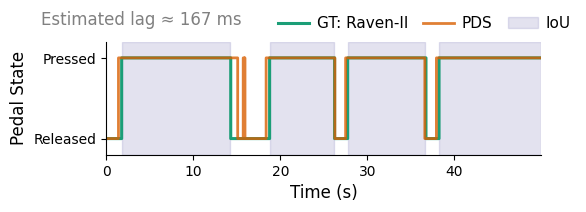

In [27]:

trials = ["t1","t2","t3","t4","t5","t6","t7"]
base_path = "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid"

complete_df = pd.DataFrame()
for trial in trials:
    csv_path = f"{base_path}/{trial}/synched_data/final_annotation_{trial}.csv"

    df = pd.read_csv(csv_path)

    complete_df = pd.concat([complete_df, df], ignore_index=True)

# drop all rows with NaN values
complete_df = complete_df.dropna()

gt_pedal_column_name =  "console_pedal"
pds_pedal_column_name = "Pedal 5 Pressesd"

# drop all rows with -1 in console_pedal
complete_df = complete_df[complete_df[gt_pedal_column_name] != -1]

# invert the "Pedal Position" column
complete_df[pds_pedal_column_name] = 1 - complete_df[pds_pedal_column_name]

window_start = 2500
window_end = 4000

# ---------- example usage ----------
f1, precision, recall, accuracy = compute_metrics(complete_df[gt_pedal_column_name], complete_df[pds_pedal_column_name])
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")

metrics = compute_pedal_metrics(
    complete_df[gt_pedal_column_name].values,
    complete_df[pds_pedal_column_name].values,
    fps=30.0,                # <-- set your true frame rate
    estimate_lag=True,       # set False if you already synchronized
    max_lag_seconds=0.5,     # search ±0.5 s
    onset_tol_ms=50,         # ±50 ms onset tolerance
    min_iou=0.5              # ≥50% overlap to count
)
print(pd.Series(metrics))

results_dir = "pedal_accuracy_results"
os.makedirs(results_dir, exist_ok=True)

# save metrics to CSV
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(f"{results_dir}/pedal_accuracy_metrics.csv", index=False)

raven_df = complete_df  # assuming complete_df is for Raven-II platform
gt_pedal_column_name_raven = gt_pedal_column_name
pds_pedal_column_name_raven = pds_pedal_column_name

plot_pedal_signals(raven_df, gt_pedal_column_name_raven, pds_pedal_column_name_raven, window_start, window_end, platform="Raven-II", results_dir=results_dir)


# Bootcamp Data Evaluation

/tmp/ipykernel_457006/2962109021.py:12: DtypeWarning: Columns (64,65,66,67,68) have mixed types. Specify dtype option on import or set low_memory=False.
  pds_sync_df = pd.read_csv(bootcamp_pds_sync_path)
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)

GT columns: ['obs_frame_idx', 'Camera_Pedal', 'Upper Left', 'Upper Right', 'Lower Left', 'Lower Right', 'Arm_Swap']
PDS columns: ['Pedal 1 Pressed', 'Pedal 2 Pressed', 'Pedal 3 Pressed', 'Pedal 4 Pressed', 'Pedal 6 Pressed', 'obs_frame_idx']
Merged columns: ['obs_frame_idx', 'Camera_Pedal', 'Upper Left', 'Upper Right', 'Lower Left', 'Lower Right', 'Arm_Swap', 'Pedal 1 Pressed', 'Pedal 2 Pressed', 'Pedal 3 Pressed', 'Pedal 4 Pressed', 'Pedal 6 Pressed']


/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the c


=== Per-pedal metrics (saved) ===
          Pedal     GT_Column       PDS_Column        F1  Precision    Recall  \
0    Upper Left    Upper Left  Pedal 1 Pressed  0.000000   0.000000  0.000000   
1   Upper Right   Upper Right  Pedal 2 Pressed  0.000000   0.000000  0.000000   
2    Lower Left    Lower Left  Pedal 3 Pressed  0.000000   0.000000  0.000000   
3   Lower Right   Lower Right  Pedal 4 Pressed  0.746781   0.598413  0.992976   
4  Camera_Pedal  Camera_Pedal  Pedal 6 Pressed  0.697140   0.730625  0.666590   

   Accuracy  Balanced_Accuracy  Temporal_IoU  Seg_Precision  ...    Seg_F1  \
0  1.000000           1.000000      1.000000       1.000000  ...  1.000000   
1  1.000000           1.000000      1.000000       1.000000  ...  1.000000   
2  1.000000           1.000000      1.000000       1.000000  ...  1.000000   
3  0.994100           0.993543      0.595890       0.000000  ...  0.000000   
4  0.980529           0.829020      0.535084       0.165644  ...  0.168224   

   Lag_Fr

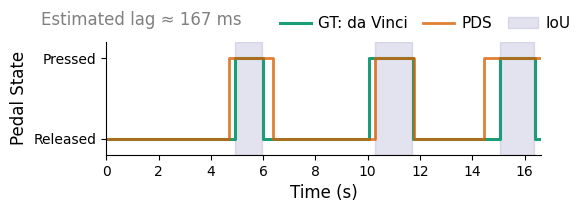

In [33]:
import os
import pandas as pd

# --- paths ---
bootcamp_pds_gt_path   = "/standard/UVA-DSA/MIDAS/Organized/Bootcamp/SuturingV2/Processed/S116_T1/synched_data/S116_T1_pds_gt.csv"
bootcamp_pds_sync_path = "/standard/UVA-DSA/MIDAS/Organized/Bootcamp/SuturingV2/Processed/S116_T1/synched_data/final_annotation_S116_T1.csv"
results_dir = "bootcamp_pedal_accuracy_results"
os.makedirs(results_dir, exist_ok=True)

# --- load ---
gt_pds_df   = pd.read_csv(bootcamp_pds_gt_path)
pds_sync_df = pd.read_csv(bootcamp_pds_sync_path)

# obs_frame_idx,Camera_Pedal,Upper Left,Upper Right,Lower Left,Lower Right,Arm_Swap
pedal_mapping = {
    'Upper Left':   'Pedal 1 Pressed',
    'Upper Right':  'Pedal 2 Pressed',
    'Lower Left':   'Pedal 3 Pressed',
    'Lower Right':  'Pedal 4 Pressed',
    'Camera_Pedal': 'Pedal 6 Pressed',
    # 'Arm_Swap':     'Pedal 7 Pressed'
}

# keep only relevant PDS columns + frame index
relevant_pds_columns = list(pedal_mapping.values()) + ['obs_frame_idx']
pds_sync_df = pds_sync_df[relevant_pds_columns]

print("GT columns:", gt_pds_df.columns.tolist())
print("PDS columns:", pds_sync_df.columns.tolist())

# --- merge on frame index ---
merged_df = pd.merge(gt_pds_df, pds_sync_df, on='obs_frame_idx', how='inner')
print("Merged columns:", merged_df.columns.tolist())

# ============================================================
# 1) Per-pedal metrics for ALL pedals + macro averages
# ============================================================
trial_id = "S116_T1"
per_pedal_df, macro_df = compute_all_pedals_metrics(
    merged_df=merged_df,
    pedal_mapping=pedal_mapping,
    pedals=None,                # None => evaluate all pedals defined in pedal_mapping
    fps=30.0,
    estimate_lag=True,
    max_lag_seconds=0.5,
    onset_tol_ms=50,
    min_iou=0.5
)

per_pedal_csv = os.path.join(results_dir, f"{trial_id}_per_pedal_metrics.csv")
macro_csv     = os.path.join(results_dir, f"{trial_id}_macro_averages.csv")
per_pedal_df.to_csv(per_pedal_csv, index=False)
macro_df.to_csv(macro_csv, index=False)

print("\n=== Per-pedal metrics (saved) ===")
print(per_pedal_df.head())
print("\n=== Macro averages (saved) ===")
print(macro_df.to_string(index=False))

# ============================================================
# 2) (Optional) Combined “energy pedals” metric (OR across UL/UR/LL/LR)
# ============================================================
energy_pedals = ['Upper Left', 'Upper Right', 'Lower Left', 'Lower Right']
energy_metrics = compute_metrics_multi(
    complete_df=merged_df,
    gt_pedals=energy_pedals,
    pedal_mapping=pedal_mapping,
    fps=30.0,
    estimate_lag=True,
    max_lag_seconds=0.5,
    onset_tol_ms=50,
    min_iou=0.5,
    mode="any"   # logical OR across the four pedals
)

energy_csv = os.path.join(results_dir, f"{trial_id}_energy_pedals_combined_metrics.csv")
pd.Series(energy_metrics).to_csv(energy_csv)
print("\n=== Combined energy pedals (OR) metrics (saved) ===")
print(pd.Series(energy_metrics))

# ============================================================
# 3) Selected pedal quick report + detailed metrics (unchanged usage)
# ============================================================
selected_gt_pedal = 'Lower Right'
selected_pds_pedal = pedal_mapping[selected_gt_pedal]

# basic
f1, precision, recall, accuracy = compute_metrics(
    merged_df[selected_gt_pedal],
    merged_df[selected_pds_pedal]
)
print(f"\n=== Basic metrics for {selected_gt_pedal} ===")
print(f"F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | Accuracy: {accuracy:.4f}")

# detailed
detailed_metrics = compute_pedal_metrics(
    merged_df[selected_gt_pedal].values,
    merged_df[selected_pds_pedal].values,
    fps=30.0,
    estimate_lag=True,
    max_lag_seconds=0.5,
    onset_tol_ms=50,
    min_iou=0.5
)
print(f"\n=== Detailed metrics for {selected_gt_pedal} ===")
# print(pd.Series(detailed_metrics))

# ============================================================
# 4) Plot a short window for visual inspection
# ============================================================
window_start = 3000
window_end   = 3500
plot_pedal_signals(
    merged_df, selected_gt_pedal, selected_pds_pedal,
    window_start=window_start, window_end=window_end,
    platform="da Vinci", results_dir=results_dir
)


## Process all trials for Bootcamp

In [ ]:
import os
import pandas as pd

# ---------------- config ----------------
ROOT_PATH = "/standard/UVA-DSA/MIDAS/Organized/Bootcamp/SuturingV2/Processed/"
TRIALS = [
    # "S116_T1",
    "S105_T1",
    "S106_T1","S106_T2","S112_T1","S112_T2","S116_T1","S116_T2","S116_T4","S116_T5",
    "S118_T1","S200_T1","S201_T1","S201_T2","S202_T1","S203_T1","S204_T1",
    "S214_T1","S214_T4","S214_T6","S215_T3","S215_T4","S217_T2","S217_T3","S217_T4","S218_T1","S219_T1",
]
RESULTS_DIR = "bootcamp_pedal_accuracy_across_trials"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Your mapping between GT columns and PDS sync columns
pedal_mapping = {
    # 'Upper Left':   'Pedal 1 Pressed',
    # 'Upper Right':  'Pedal 2 Pressed',
    # 'Lower Left':   'Pedal 3 Pressed',
    'Lower Right':  'Pedal 4 Pressed',
    'Camera_Pedal': 'Pedal 6 Pressed',
    # 'Arm_Swap':     'Pedal 7 Pressed'
}

# -------------- collect per-trial results --------------
all_rows = []   # per-pedal-per-trial table

for trial in TRIALS:
    gt_path  = f"{ROOT_PATH}/{trial}/synched_data/{trial}_pds_gt.csv"
    pds_path = f"{ROOT_PATH}/{trial}/synched_data/final_annotation_{trial}.csv"
    pds_path = f"{ROOT_PATH}/{trial}/synched_data/final_annotation_{trial}_optimized.csv"

    if not os.path.isfile(gt_path):
        print(f"❌ Missing GT: {gt_path} — skipping")
        continue
    if not os.path.isfile(pds_path):
        print(f"❌ Missing PDS sync: {pds_path} — skipping")
        continue

    gt_df   = pd.read_csv(gt_path)
    pds_df  = pd.read_csv(pds_path)

    # keep only relevant PDS columns + frame index
    keep_cols = list(pedal_mapping.values()) + ['obs_frame_idx']
    missing = [c for c in keep_cols if c not in pds_df.columns]
    if missing:
        print(f"❌ {trial}: PDS missing columns {missing} — skipping")
        continue
    pds_df = pds_df[keep_cols]

    # merge
    merged_df = pd.merge(gt_df, pds_df, on='obs_frame_idx', how='inner')

    # compute per-pedal metrics for this trial (adds Support_Positive)
    per_pedal_df, macro_df = compute_all_pedals_metrics(
        merged_df=merged_df,
        pedal_mapping=pedal_mapping,
        pedals=None,                 # all pedals in mapping
        fps=30.0,
        estimate_lag=True,
        max_lag_seconds=0.5,
        onset_tol_ms=50,
        min_iou=0.5,
        exclude_inactive=True        # exclude Support_Positive==0 from macro inside the function
    )
    if per_pedal_df.empty:
        print(f"⚠️ {trial}: No pedals evaluated.")
        continue

    per_pedal_df.insert(0, "Trial", trial)
    all_rows.append(per_pedal_df)

# -------------- aggregate across trials --------------
if not all_rows:
    print("No results to aggregate.")
else:
    all_per_pedal = pd.concat(all_rows, ignore_index=True)
    all_csv = os.path.join(RESULTS_DIR, "all_trials_per_pedal_metrics.csv")
    all_per_pedal.to_csv(all_csv, index=False)
    print(f"✅ Saved per-pedal per-trial metrics → {all_csv}")

    # Per-pedal averages across trials:
    # EXCLUDE trials where that pedal had Support_Positive==0 (inactive)
    # active_mask = all_per_pedal["Support_Positive"] > 0
    active_mask = (all_per_pedal["Support_Positive"] > 0) & all_per_pedal["F1"].notna() & (all_per_pedal["F1"] > 0)

    active_only = all_per_pedal[active_mask].copy()

    # If a pedal is never active in any trial, it will drop out—this is desired.
    agg_funcs = {
        "F1": "mean",
        "Precision": "mean",
        "Recall": "mean",
        "Accuracy": "mean",
        "Balanced_Accuracy": "mean",
        "Temporal_IoU": "mean",
        "Seg_Precision": "mean",
        "Seg_Recall": "mean",
        "Seg_F1": "mean",
        "Lag_ms": "mean",
        "Spurious_per_min": "mean",
        # counts for transparency
        "Support_Positive": "sum",
        "GT_Segments": "sum",
        "Pred_Segments": "sum",
        "Frames": "sum",
    }
    per_pedal_avg = (
        active_only
        .groupby("Pedal", as_index=False)
        .agg(agg_funcs)
        .rename(columns={
            "Support_Positive": "Total_Positive_Frames",
            "GT_Segments": "Total_GT_Segments",
            "Pred_Segments": "Total_Pred_Segments",
            "Frames": "Total_Frames_Contributed"
        })
    )
    per_pedal_avg_csv = os.path.join(RESULTS_DIR, "per_pedal_averages_across_trials.csv")
    per_pedal_avg.to_csv(per_pedal_avg_csv, index=False)
    print(f"✅ Saved per-pedal averages → {per_pedal_avg_csv}")

    # Overall macro averages across ALL active pedal–trial entries
    overall_macro = pd.DataFrame([{
        "Avg_F1": active_only["F1"].mean(),
        "Avg_Precision": active_only["Precision"].mean(),
        "Avg_Recall": active_only["Recall"].mean(),
        "Avg_Accuracy": active_only["Accuracy"].mean(),
        "Avg_Balanced_Accuracy": active_only["Balanced_Accuracy"].mean(),
        "Avg_Temporal_IoU": active_only["Temporal_IoU"].mean(),
        "Avg_Seg_F1": active_only["Seg_F1"].mean(),
        "Avg_Lag_ms": active_only["Lag_ms"].mean(),
        "Avg_Spurious_per_min": active_only["Spurious_per_min"].mean(),
        "Active_Pedal_Trial_Instances": int(len(active_only)),
        "Unique_Active_Pedals": int(active_only["Pedal"].nunique()),
        "Unique_Trials": int(active_only["Trial"].nunique()),
    }])
    overall_macro_csv = os.path.join(RESULTS_DIR, "overall_macro_averages_across_trials.csv")
    overall_macro.to_csv(overall_macro_csv, index=False)
    print(f"✅ Saved overall macro averages → {overall_macro_csv}")


/tmp/ipykernel_457006/3576423471.py:43: DtypeWarning: Columns (66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  pds_df  = pd.read_csv(pds_path)
/tmp/ipykernel_457006/3576423471.py:43: DtypeWarning: Columns (58,59,60,61,62) have mixed types. Specify dtype option on import or set low_memory=False.
  pds_df  = pd.read_csv(pds_path)
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/si

✅ Saved per-pedal per-trial metrics → bootcamp_pedal_accuracy_across_trials/all_trials_per_pedal_metrics.csv
✅ Saved per-pedal averages → bootcamp_pedal_accuracy_across_trials/per_pedal_averages_across_trials.csv
✅ Saved overall macro averages → bootcamp_pedal_accuracy_across_trials/overall_macro_averages_across_trials.csv


In [ ]:
# do both plot_pedal_signals for two datasets in one figure stacked vertically and share the x-axis label

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_pedal_signals_compare(
    cfg1: dict,
    cfg2: dict,
    results_dir: str,
    filename: str = "pedal_accuracy_comparison_two_datasets.pdf",
):
    """
    Plot two pedal-signal timelines stacked vertically.
    Each cfg is a dict with:
      - 'complete_df': DataFrame
      - 'gt_pedal_column_name': str
      - 'pds_pedal_column_name': str
      - 'window_start': int
      - 'window_end': int
      - 'platform': str
      - (optional) 'fps': float (default 30.0)
      - (optional) 'lag_frames': int (default 5)
    """

    def _extract(cfg):
        df      = cfg['complete_df']
        ws      = cfg['window_start']
        we      = cfg['window_end']
        fps     = cfg.get('fps', 30.0)
        frames  = np.arange(ws, we)
        time_s  = (frames - ws) / fps
        filtered_df = df.iloc[ws:we].copy()
        gt   = filtered_df[cfg['gt_pedal_column_name']].to_numpy()
        pds  = filtered_df[cfg['pds_pedal_column_name']].to_numpy()
        lag_frames = cfg.get('lag_frames', 5)
        platform   = cfg['platform']
        return time_s, gt, pds, fps, lag_frames, platform

    # --- Extract both ---
    t1, gt1, pds1, fps1, lag1, plat1 = _extract(cfg1)
    t2, gt2, pds2, fps2, lag2, plat2 = _extract(cfg2)

    # --- Styling reset ---
    sns.reset_orig()

    # --- Figure & axes ---
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(6, 3.5), sharex=False,
        gridspec_kw={'hspace': 0.9}
    )

    # Common style values
    gt_color = '#1b9e77'
    pds_color = '#d95f02'
    overlap_color = '#7570b3'

    # Helper to draw one panel
    def _draw_panel(ax, time_s, gt, pds, fps, lag_frames, platform):
        ax.step(time_s, gt, where='post', linewidth=2.2, color=gt_color, label=f'GT: {platform}')
        ax.step(time_s, pds, where='post', linewidth=2.0, color=pds_color, alpha=0.8, label='PDS')

        overlap = np.logical_and(gt == 1, pds == 1)
        ax.fill_between(
            time_s, 0, 1,
            where=overlap,
            color=overlap_color, alpha=0.2,
            transform=ax.get_xaxis_transform(),
            label='IoU'
        )

        ax.set_ylabel('Pedal State', fontsize=12)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['Released', 'Pressed'])
        ax.set_ylim(-0.2, 1.2)
        ax.set_xlim(time_s[0], time_s[-1])

        if platform == "Raven-II":
            ax.text(
                0.5, -0.6,                # x, y (in axis fraction coordinates)
                f"(a) {platform} Pedal Signals", 
                fontsize=12, 
                ha='center', va='top', 
                transform=ax.transAxes
            )
        else:
            ax.text(
                0.5, -0.25,                # x, y (in axis fraction coordinates)
                f"(b) {platform} Pedal Signals", 
                fontsize=12, 
                ha='center', va='top', 
                transform=ax.transAxes
            )

        # Legend above the axis (one row, frameless), matching your original placement
        ax.legend(
            loc='upper right',
            bbox_to_anchor=(1.1, 1.35),
            ncol=3,
            frameon=False,
            fontsize=11,
            handletextpad=0.5,
            columnspacing=1.0
        )

        # Lag annotation
        lag_ms = lag_frames * 1000.0 / fps
        ax.text(
            -0.15, 1.15, f'Estimated lag ≈ {lag_ms:.0f} ms',
            transform=ax.transAxes, fontsize=12, color='gray'
        )

        sns.despine(ax=ax)

    # Draw both panels
    _draw_panel(ax1, t1, gt1, pds1, fps1, lag1, plat1)
    _draw_panel(ax2, t2, gt2, pds2, fps2, lag2, plat2)

    # Top axis: hide x tick labels (you asked to share the x-axis label, not ticks)
    ax1.set_xticklabels([])

    # Bottom axis: keep ticks; global shared xlabel for the figure
    ax2.set_xlabel('Time (s)', fontsize=12)

    plt.tight_layout()
    out_path = f"{results_dir.rstrip('/')}/{filename}"
    plt.savefig(out_path, format='png', dpi=300, bbox_inches='tight')
    plt.show()
    return out_path

# -------------------
# Example usage:


cfg_raven = dict(
    complete_df=raven_df,
    gt_pedal_column_name=gt_pedal_column_name_raven,
    pds_pedal_column_name=pds_pedal_column_name_raven,
    window_start=2500,
    window_end=4000,
    platform="Raven-II",
    fps=30.0,
    lag_frames=5
)

cfg_dv = dict(
    complete_df=davinci_df,
    gt_pedal_column_name=gt_pedal_column_name_dv,
    pds_pedal_column_name=pds_pedal_column_name_dv,
    window_start=3000,
    window_end=3500,
    platform="da Vinci",
    fps=30.0,
    lag_frames=4
)

results_pdf = plot_pedal_signals_compare(cfg_dv, cfg_raven, results_dir, filename="raven_vs_dv_pedals.png")


# choose any set of pedals (1, 2, or more)
group = ['Lower Right', 'Upper Left']  # e.g., combine LR and UL
res_any = compute_metrics_multi(
    complete_df, group, pedal_mapping,
    fps=30.0, estimate_lag=True, max_lag_seconds=0.5,
    onset_tol_ms=50, min_iou=0.5, mode="any"   # OR-combine
)
print("Combined (ANY) metrics:\n", pd.Series(res_any))

# AND-combined (only when all selected pedals are pressed simultaneously)
res_all = compute_metrics_multi(
    complete_df, group, pedal_mapping, mode="all"
)
print("Combined (ALL) metrics:\n", pd.Series(res_all))


In [ ]:
# do both plot_pedal_signals for two datasets in one figure stacked vertically and share the x-axis label

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from typing import List, Union

def _as_list(x: Union[str, List[str]]) -> List[str]:
    if isinstance(x, str):
        return [x]
    if isinstance(x, (list, tuple)):
        return list(x)
    raise TypeError("Pedal column names must be a string or list of strings.")

def _combine_binary_cols(df: pd.DataFrame, cols: List[str], mode: str = "any") -> np.ndarray:
    """Combine multiple binary columns into a single 0/1 vector using OR ('any') or AND ('all')."""
    if len(cols) == 0:
        raise ValueError("No columns provided to combine.")
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in DataFrame: {missing}")
    data = df[cols].astype(int).to_numpy()
    if mode.lower() == "any":
        combined = (data.sum(axis=1) > 0).astype(int)
    elif mode.lower() == "all":
        combined = (data.sum(axis=1) == data.shape[1]).astype(int)
    else:
        raise ValueError("mode must be 'any' or 'all'.")
    return combined

def plot_pedal_signals_compare(
    cfg1: dict,
    cfg2: dict,
    results_dir: str,
    filename: str = "pedal_accuracy_comparison_two_datasets.pdf",
):
    """
    Plot two pedal-signal timelines stacked vertically, supporting multi-pedal combinations.

    Each cfg is a dict with:
      - 'complete_df': DataFrame (must include the pedal columns)
      - 'gt_pedal_column_names': str | list[str]   (GT pedal column(s) to combine)
      - 'pds_pedal_column_names': str | list[str]  (PDS pedal column(s) to combine)
      - 'window_start': int  (inclusive)
      - 'window_end': int    (exclusive)
      - 'platform': str
      - (optional) 'fps': float (default 30.0)
      - (optional) 'lag_frames': int (default 5)   [displayed as annotation only]
      - (optional) 'combine_mode': 'any' or 'all' (default 'any')

    The GT and PDS signals are each combined across their specified columns using combine_mode.
    """

    def _extract(cfg):
        df       = cfg['complete_df']
        ws       = int(cfg['window_start'])
        we       = int(cfg['window_end'])
        fps      = float(cfg.get('fps', 30.0))
        lag_fr   = int(cfg.get('lag_frames', 5))
        platform = cfg['platform']
        mode     = cfg.get('combine_mode', 'any')

        gt_cols  = _as_list(cfg['gt_pedal_column_names'])
        pds_cols = _as_list(cfg['pds_pedal_column_names'])

        # slice window
        filtered_df = df.iloc[ws:we].copy()
        frames  = np.arange(ws, we)
        time_s  = (frames - ws) / fps

        gt_comb  = _combine_binary_cols(filtered_df, gt_cols, mode=mode)
        pds_comb = _combine_binary_cols(filtered_df, pds_cols, mode=mode)

        # For the subtitle annotation
        gt_label  = " + ".join(gt_cols)  if mode == "any" else " ∧ ".join(gt_cols)
        pds_label = " + ".join(pds_cols) if mode == "any" else " ∧ ".join(pds_cols)

        return time_s, gt_comb, pds_comb, fps, lag_fr, platform, mode, gt_label, pds_label

    # --- Extract both ---
    t1, gt1, pds1, fps1, lag1, plat1, mode1, gt_lbl1, pds_lbl1 = _extract(cfg1)
    t2, gt2, pds2, fps2, lag2, plat2, mode2, gt_lbl2, pds_lbl2 = _extract(cfg2)

    # --- Styling reset ---
    sns.reset_orig()

    # --- Figure & axes ---
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(6.4, 3.8), sharex=False,
        gridspec_kw={'hspace': 0.9}
    )

    # Common style values
    gt_color = '#1b9e77'
    pds_color = '#d95f02'
    overlap_color = '#7570b3'

    def _draw_panel(ax, time_s, gt, pds, fps, lag_frames, platform, mode, gt_label, pds_label, panel_tag):
        # signals
        ax.step(time_s, gt, where='post', linewidth=2.2, color=gt_color, label=f'GT : {gt_label}')
        ax.step(time_s, pds, where='post', linewidth=2.0, color=pds_color, alpha=0.9, label=f'PDS : {pds_label}')

        # overlap shading
        overlap = np.logical_and(gt == 1, pds == 1)
        ax.fill_between(
            time_s, 0, 1,
            where=overlap,
            color=overlap_color, alpha=0.2,
            transform=ax.get_xaxis_transform(),
            label='Overlap'
        )

        # axes cosmetics
        ax.set_ylabel('Pedal State', fontsize=12)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['Released', 'Pressed'])
        ax.set_ylim(-0.2, 1.2)
        ax.set_xlim(time_s[0], time_s[-1])

        # panel label below the axis for subtitle-like placement
        ax.text(
            0.5, -0.35, f"{panel_tag}) {platform} Pedal Signals",
            fontsize=12, ha='center', va='top', transform=ax.transAxes
        )

        # legend above the axis, single row
        ax.legend(
            loc='upper right',
            bbox_to_anchor=(1.0, 1.35),
            ncol=3,
            frameon=False,
            fontsize=9,
            handletextpad=0.5,
            columnspacing=1.0
        )

        # lag annotation
        lag_ms = lag_frames * 1000.0 / fps
        ax.text(
            -0.12, 1.12, f'Estimated lag ≈ {lag_ms:.0f} ms',
            transform=ax.transAxes, fontsize=10, color='gray'
        )

        sns.despine(ax=ax)

    # Draw both panels
    _draw_panel(ax1, t1, gt1, pds1, fps1, lag1, plat1, mode1, gt_lbl1, pds_lbl1, panel_tag="(a)")
    _draw_panel(ax2, t2, gt2, pds2, fps2, lag2, plat2, mode2, gt_lbl2, pds_lbl2, panel_tag="(b)")

    # Top axis: hide x tick labels
    ax1.set_xticklabels([])

    # Bottom axis: shared xlabel
    ax2.set_xlabel('Time (s)', fontsize=12)

    plt.tight_layout()

    # Save using extension-derived format
    out_path = f"{results_dir.rstrip('/')}/{filename}"
    fmt = filename.split('.')[-1].lower()
    plt.savefig(out_path, format=fmt, dpi=300, bbox_inches='tight')
    plt.show()
    return out_path


# -------------------
# Example usage:
cfg_raven = dict(
    complete_df=raven_df,
    gt_pedal_column_names=gt_pedal_column_name_raven,
    pds_pedal_column_names=pds_pedal_column_name_raven,
    window_start=2500,
    window_end=4000,
    platform="Raven-II",
    fps=30.0,
    lag_frames=5
)

cfg_dv = dict(
    complete_df=davinci_df,
    gt_pedal_column_names=['Lower Right', 'Upper Right'],        # also accepts single string
    pds_pedal_column_names=['Pedal 4 Pressed', 'Pedal 2 Pressed'],  # also accepts single string
    window_start=3000,
    window_end=3500,
    platform="da Vinci",
    fps=30.0,
    lag_frames=4,
    combine_mode='all'
)


results_path = plot_pedal_signals_compare(cfg_dv, cfg_raven, results_dir, filename="raven_vs_dv_pedals.png")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score


# trials list
pds_trials = [
    "/standard/UVA-DSA/MIDAS/Organized/Bootcamp/SuturingV2/Processed/S116_T1",
    "/standard/UVA-DSA/MIDAS/Organized/Bootcamp/SuturingV2/Processed/S219_T1"
]

gt_pds_trials = [
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S116_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S219_T1_2024-07-19"
]


complete_df = pd.DataFrame()

for pds_trial, gt_trial in zip(pds_trials, gt_pds_trials):
    gt_pds_df = pd.read_csv(f"{gt_trial}/pedal_detection.csv")
    trial_id = pds_trial.split("/")[-1]
    print(f"Processing trial: {trial_id}")
    pds_sync_df = pd.read_csv(f"{pds_trial}/synched_data/final_annotation_{trial_id}.csv")

    # get only the relevant columns from pds_sync_df based on pedal_mapping values
    relevant_pds_columns = list(pedal_mapping.values())
    relevant_pds_columns.append('obs_frame_idx')  # also keep obs_frame_idx for merging
    pds_sync_df = pds_sync_df[relevant_pds_columns]
    # merge dataframes on frame index
    merged_df = pd.merge(gt_pds_df, pds_sync_df, left_on='Frame Num', right_on='obs_frame_idx', how='inner')  
    merged_df['trial_id'] = trial_id  # add trial identifier
    complete_df = pd.concat([complete_df, merged_df], ignore_index=True)

# drop all rows with NaN values
complete_df = complete_df.dropna()


# map GT -> PDS column names
pedal_mapping = {
    "Upper Left":  "Pedal 1 Pressed",
    "Upper Right": "Pedal 2 Pressed",
    "Lower Left":  "Pedal 3 Pressed",
    "Lower Right": "Pedal 4 Pressed",
}

# ---- helpers ----
def binarize_series(s: pd.Series) -> pd.Series:
    """
    Robustly coerce a pedal column to binary {0,1}.
    Handles ints/floats/booleans/strings like '1','0','true','false','Pressed','Released'.
    """
    if s.dtype == bool:
        return s.astype(int)

    # Lowercase strings for mapping, but keep a numeric attempt first
    s_str = s.astype(str).str.strip().str.lower()

    # common textual encodings
    txt_map = {
        "true": 1, "t": 1, "yes": 1, "y": 1, "pressed": 1, "1": 1,
        "false": 0, "f": 0, "no": 0, "n": 0, "released": 0, "0": 0, "nan": np.nan, "": np.nan
    }
    mapped = s_str.map(txt_map)

    # try numeric first; where numeric fails, use mapped
    numeric = pd.to_numeric(s, errors="coerce")
    out = numeric.where(~numeric.isna(), mapped)

    # final fallback: anything > 0 -> 1 else 0 (NaNs -> 0)
    out = out.fillna(0).astype(float)
    return (out > 0).astype(int)

def compute_metrics(gt: pd.Series, pred: pd.Series):
    # ensure 0/1 ints
    gt_b = binarize_series(gt)
    pr_b = binarize_series(pred)
    # diagnostics
    gt_pos = int(gt_b.sum())
    pr_pos = int(pr_b.sum())

    # guard: if both are single class, sklearn can warn; metrics still defined
    f1  = f1_score(gt_b, pr_b, zero_division=0)
    prec = precision_score(gt_b, pr_b, zero_division=0)
    rec  = recall_score(gt_b, pr_b, zero_division=0)
    acc  = accuracy_score(gt_b, pr_b)
    return {
        "gt_pos": gt_pos,
        "pred_pos": pr_pos,
        "F1": f1,
        "Precision": prec,
        "Recall": rec,
        "Accuracy": acc
    }

# ---- load ----
df_gt  = pd.read_csv(gt_path, low_memory=False)
df_pds = pd.read_csv(pds_path, low_memory=False)

required_gt_cols  = ["Frame Num"] + list(pedal_mapping.keys())
required_pds_cols = ["obs_frame_idx"] + list(pedal_mapping.values())

missing_gt  = [c for c in required_gt_cols if c not in df_gt.columns]
missing_pds = [c for c in required_pds_cols if c not in df_pds.columns]
if missing_gt or missing_pds:
    raise KeyError(f"Missing GT cols: {missing_gt} | Missing PDS cols: {missing_pds}")

# merge by frame index
merged = pd.merge(
    df_gt[required_gt_cols],
    df_pds[required_pds_cols],
    left_on="Frame Num",
    right_on="obs_frame_idx",
    how="inner"
).dropna()

# ---- metrics per pedal ----
print("========== Pedal Accuracy Metrics ==========")
print(f"{'Pedal':<15} {'GT+':>6} {'PDS+':>6} {'F1':>8} {'Precision':>12} {'Recall':>10} {'Accuracy':>12}")
print("-" * 80)

for gt_col, pds_col in pedal_mapping.items():
    m = compute_metrics(merged[gt_col], merged[pds_col])
    print(f"{gt_col:<15} {m['gt_pos']:6d} {m['pred_pos']:6d} {m['F1']:8.3f} {m['Precision']:12.3f} {m['Recall']:10.3f} {m['Accuracy']:12.3f}")

print("-" * 80)
print(f"Rows after merge: {len(merged)}")


# visualize all gt pedals

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Pretty labels for plot titles/printing (do not use these as DF column names)
labels = {
    'Upper Left':  'Pedal 1 Pressed',
    'Upper Right': 'Pedal 2 Pressed',
    'Lower Left':  'Pedal 3 Pressed',
    'Lower Right': 'Pedal 4 Pressed',
}

def sGT(df, labels=labels):
    """Plot GT pedal position columns against Frame Num."""
    required = ['Frame Num'] + list(labels.keys())
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    for pedal_col, pretty in labels.items():
        plt.figure(figsize=(10, 4))
        plt.plot(df['Frame Num'], df[pedal_col], label='GT Pedal Position')
        plt.xlabel('Frame Number')
        plt.ylabel('Pedal Position Value')
        plt.title(f'GT Pedal Position: {pretty}')
        plt.legend()
        plt.tight_layout()
        plt.show()

gt_pds_trials = [
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/Bowel_S207_T2_2024-07-18",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/Bowel_S216_T1_2024-07-18",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/BOWL_ANAS_S207_T1_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/BOWL_ANAS_S207_T2_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/ESL_S203_T1_2024-07-16",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/ESL_S207_T1_2024-07-16",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/Gyno_S11_T1_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/InguinalH_S210_T1_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/PEGT_S118_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/PegT_S220_T2_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S116_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S219_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VH1_S203_T1_2024-07-16",
]

# Load all trials
complete_df = pd.DataFrame()
for gt_trial in gt_pds_trials:
    csv_path = Path(gt_trial) / "pedal_detection.csv"
    if not csv_path.exists():
        print(f"[WARN] Missing file: {csv_path}")
        continue
    gt_pds_df = pd.read_csv(csv_path)
    complete_df = pd.concat([complete_df, gt_pds_df], ignore_index=True)

# Plot
sGT(complete_df, labels=labels)

# Generic percentage function
def compute_pressed_percentage(df, pedal_column):
    if pedal_column not in df.columns:
        raise KeyError(f"Column not found: {pedal_column}")
    pressed_count = df[pedal_column].sum()
    total_count = len(df)
    return (pressed_count / total_count) * 100 if total_count > 0 else 0

# Use DF column names (keys), not the pretty labels (values)
for pedal_col, pretty in labels.items():
    percentage = compute_pressed_percentage(complete_df, pedal_col)
    print(f"{pedal_col} ({pretty}) Pressed Percentage: {percentage:.2f}%")


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ---- Config: GT pedal columns ----
pedal_cols = ['Upper Left', 'Upper Right', 'Lower Left', 'Lower Right']

# ---- Optional: plotting (kept from your code) ----
def sGT(df, labels: dict, frame_idx_col: str = 'Frame Num'):
    required = [frame_idx_col] + list(labels.keys())
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")
    import matplotlib.pyplot as plt
    for pedal_col, pretty in labels.items():
        plt.figure(figsize=(10, 4))
        plt.plot(df[frame_idx_col], df[pedal_col], label='GT Pedal Position')
        plt.xlabel('Frame Number')
        plt.ylabel('Pedal Position Value')
        plt.title(f'GT Pedal Position: {pretty}')
        plt.legend()
        plt.tight_layout()
        plt.show()

labels = {
    'Upper Left':  'Pedal 1 Pressed',
    'Upper Right': 'Pedal 2 Pressed',
    'Lower Left':  'Pedal 3 Pressed',
    'Lower Right': 'Pedal 4 Pressed',
}

gt_pds_trials = [
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/Bowel_S207_T2_2024-07-18",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/Bowel_S216_T1_2024-07-18",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/BOWL_ANAS_S207_T1_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/BOWL_ANAS_S207_T2_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/ESL_S203_T1_2024-07-16",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/ESL_S207_T1_2024-07-16",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/Gyno_S11_T1_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/InguinalH_S210_T1_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/PEGT_S118_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/PegT_S220_T2_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S116_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S219_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VH1_S203_T1_2024-07-16",
]

def _binarize(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = (pd.to_numeric(out[c], errors='coerce').fillna(0) > 0).astype(int)
    return out

def compute_trial_usage(df: pd.DataFrame, trial_id: str, pedal_cols: list[str]) -> dict:
    """
    Returns:
      {
        'trial_id': str,
        'frames': int,
        '<pedal>%': float for each pedal (percent of total frames),
        '<pedal>_share%': float for each pedal (percent of active frames; sums to 100% if any pedal active),
      }
    """
    # Ensure binary 0/1
    df = _binarize(df, pedal_cols)
    n = len(df)
    res = {'trial_id': trial_id, 'frames': n}

    # Percent of total frames (can sum >100% if pedals overlap)
    for p in pedal_cols:
        res[f'{p}%'] = 100.0 * df[p].sum() / n if n > 0 else 0.0

    # Share of active time (sums to 100% per trial if there is any activity)
    any_active = df[pedal_cols].sum(axis=1) > 0
    active_n = int(any_active.sum())
    for p in pedal_cols:
        if active_n > 0:
            res[f'{p}_share%'] = 100.0 * df.loc[any_active, p].sum() / active_n
        else:
            res[f'{p}_share%'] = np.nan

    return res

# ---- Per-trial loop & aggregation ----
trial_rows = []
for trial_dir in gt_pds_trials:
    csv_path = Path(trial_dir) / "pedal_detection.csv"
    if not csv_path.exists():
        print(f"[WARN] Missing file: {csv_path}")
        continue
    df = pd.read_csv(csv_path, low_memory=False)
    missing = [c for c in pedal_cols if c not in df.columns]
    if missing:
        print(f"[WARN] Missing columns in {csv_path.name}: {missing}")
        continue

    trial_id = Path(trial_dir).name
    trial_rows.append(compute_trial_usage(df, trial_id, pedal_cols))

trial_stats = pd.DataFrame(trial_rows)

# ---- Report per-trial table ----
if not trial_stats.empty:
    # Pretty order: trial_id, frames, per-pedal %, per-pedal share%
    ordered_cols = (
        ['trial_id', 'frames'] +
        [f'{p}%' for p in pedal_cols] +
        [f'{p}_share%' for p in pedal_cols]
    )
    trial_stats = trial_stats[ordered_cols]
    print("\nPer-trial pedal usage (% of frames) and share-of-active-time (%):")
    print(trial_stats.to_string(index=False))

    # ---- Averages across trials ----
    # Macro (unweighted by duration)
    macro_avg = trial_stats[[f'{p}%' for p in pedal_cols]].mean().rename('macro_avg_% (per pedal)')
    macro_share = trial_stats[[f'{p}_share%' for p in pedal_cols]].mean().rename('macro_avg_share% (per pedal)')

    # Micro (duration-weighted by frames)
    w = trial_stats['frames']
    micro_avg_vals = []
    micro_share_vals = []
    for p in pedal_cols:
        micro_avg_vals.append(np.average(trial_stats[f'{p}%'], weights=w))
        # For share, weight by frames with activity is more precise, but frames approximates across trials
        micro_share_vals.append(np.average(trial_stats[f'{p}_share%'], weights=w))
    micro_avg = pd.Series(micro_avg_vals, index=[f'{p}%' for p in pedal_cols], name='micro_avg_% (per pedal)')
    micro_share = pd.Series(micro_share_vals, index=[f'{p}_share%' for p in pedal_cols], name='micro_avg_share% (per pedal)')

    print("\nOverall per-pedal averages across trials:")
    print(pd.concat([macro_avg, micro_avg], axis=1))

    print("\nOverall per-pedal share-of-active-time averages across trials (sums ~100% per trial):")
    print(pd.concat([macro_share, micro_share], axis=1))

else:
    print("No valid trials loaded.")


In [ ]:
# camera pedal state plot
camera_pedal_gt_csv = "/home/cjh9fw/Desktop/2025/DataCollectionSystem/analysis/PDS_analysys/davinci_pedal_extraction/out_color_changes/frame_metrics.csv"
camera_df = pd.read_csv(camera_pedal_gt_csv)
sGT(camera_df, labels={'changed': 'camera'}, frame_idx_col='Frame Num')

print(len(camera_df))

pds_camera_csv = "/standard/UVA-DSA/MIDAS/Organized/Bootcamp/SuturingV2/Processed/S116_T1/synched_data/final_annotation_S116_T1.csv"
pds_camera_df = pd.read_csv(pds_camera_csv)
sGT(pds_camera_df, labels={'Pedal 6 Pressed': 'camera'}, frame_idx_col='obs_frame_idx')

print(len(pds_camera_df))
